# Multimodal In-Context Learning with Open-Source Models

This notebook demonstrates how to perform few-shot (in-context) learning for image classification using several popular open-source multimodal models.

We will perform the following steps:
1.  **Install Libraries**: Install all required packages from `requirements.txt`.
2.  **Load Datasets**: Load four different image datasets: Flower102, Oxford-IIIT Pets, CIFAR-10, and DTD (Describable Textures Dataset).
3.  **Load Models**: Set up functions to load the following models from Hugging Face in 4-bit precision:
    *   LLaVA 1.5 (7B)
    *   Gemma3 (12B) - Representing the Gemma family.
    *   BakLLaVA (Mistral 7B Base)
    *   Qwen-VL
4.  **Run In-Context Learning**: For a given dataset, we will show the model a few example images and their labels, then ask it to classify a new, unseen image.

## 1. Setup and Installation

In [1]:
import torch
import torchvision
from torchvision.datasets import Flowers102, OxfordIIITPet, CIFAR10, DTD
from torchvision import transforms as T
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig
from PIL import Image
import requests
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import transformers

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Transformers version: {transformers.__version__}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Transformers version: 4.57.6


## 2. Load Datasets

Here we'll load the four datasets. We'll use `torchvision.datasets` which makes it easy to download and access them. We'll also create a simple utility to display images and their labels.

Loading Flower102...
Loading OxfordPets...
Loading CIFAR-10...
Loading DTD...
All datasets loaded.


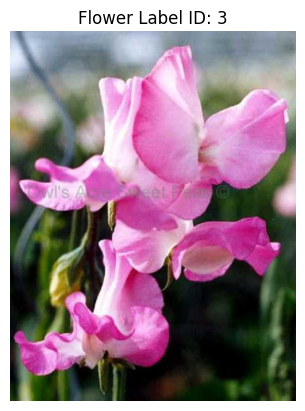

In [2]:
def load_datasets(data_dir='./data'):
    """Downloads and loads all four datasets."""
    datasets = {}
    transform = T.Compose([T.ToTensor()])
    
    print("Loading Flower102...")
    datasets['flowers'] = Flowers102(root=data_dir, split='train', download=True, transform=transform)
    # Note: Flower102 labels are 0-101. For simplicity, we'll just show the label ID.
    
    print("Loading OxfordPets...")
    datasets['pets'] = OxfordIIITPet(root=data_dir, split='trainval', download=True, transform=transform)
    datasets['pets_classes'] = datasets['pets'].classes

    print("Loading CIFAR-10...")
    datasets['cifar10'] = CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    datasets['cifar10_classes'] = datasets['cifar10'].classes

    print("Loading DTD...")
    datasets['dtd'] = DTD(root=data_dir, split='train', download=True, transform=transform)
    datasets['dtd_classes'] = datasets['dtd'].classes
    
    print("All datasets loaded.")
    return datasets

datasets = load_datasets()

def show_image(image_tensor, title=''):
    """Displays a single image tensor."""
    if isinstance(image_tensor, torch.Tensor):
        image = T.ToPILImage()(image_tensor)
    else:  # Already a PIL image
        image = image_tensor
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Example: Show a random image from the Flowers dataset
sample_idx = random.randint(0, len(datasets['flowers']) - 1)
image, label = datasets['flowers'][sample_idx]
show_image(image, title=f"Flower Label ID: {label}")

## 3. Model Loading

We'll define a function to load a multimodal model and its processor from Hugging Face. We're using `BitsAndBytesConfig` to load the models in 4-bit precision, which significantly reduces memory usage and makes it possible to run these large models on consumer GPUs.

In [9]:
MODEL_IDS = {
    "llava": "llava-hf/llava-1.5-7b-hf",
    "gemma3": "google/gemma-3-12b-it",
    "bakllava": "llava-hf/bakLlava-v1-hf",
    "qwen-vl": "Qwen/Qwen-VL-Chat",
}

g_model = None
g_processor = None

def load_model_globally(model_name):
    """Loads a specified model and its processor into global variables."""
    global g_model, g_processor
    
    model_id = MODEL_IDS.get(model_name.lower())
    if not model_id:
        raise ValueError(
            f"Unknown model: {model_name}. Available models: {list(MODEL_IDS.keys())}"
        )

    print(f"Loading model: {model_id}...")

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

    # Qwen requires trusting remote code
    trust_remote_code = "qwen" in model_name.lower()

    g_model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quantization_config,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=trust_remote_code,
    )

    g_processor = AutoProcessor.from_pretrained(model_id)

    print(f"Model {model_id} loaded successfully.")

## 4. In-Context Learning for Image Classification

This is the core of the notebook. We'll create a function `run_few_shot_inference` that constructs a prompt for a model.

The prompt will contain:
*   A general instruction (e.g., "Classify the following image.")
*   A few "shots" or examples, where each shot is an image paired with its correct label.
*   The final query image that we want the model to classify.

The prompt structure is critical and can differ between models. LLaVA-style models use `<image>` tokens in the text, while PaliGemma has a simpler `\n` separated format.

In [16]:
def get_prompt(model_name, shots, query_image, class_names=None):
    """Constructs a model-specific few-shot prompt."""

    # Convert tensors to PIL images
    shot_images = [T.ToPILImage()(shot[0]) for shot in shots]
    query_image_pil = T.ToPILImage()(query_image[0])
    shot_labels = [shot[1] for shot in shots]

    # Use class names if available, otherwise use raw label IDs
    if class_names:
        shot_labels_text = [class_names[l] for l in shot_labels]
    else:
        shot_labels_text = [str(l) for l in shot_labels]

    images = shot_images + [query_image_pil]

    # LLaVA and Qwen use a similar chat format with <image> tokens
    if "llava" in model_name or "qwen" in model_name:
        prompt_text = "You are an expert at image classification. Classify the final image based on the examples provided.\n"
        for i, label_text in enumerate(shot_labels_text):
            prompt_text += f"<image>\nThis is an image of a {label_text}.\n"
        prompt_text += "<image>\nThis is an image of a"

    # Gemma3 uses a different prompt structure
    elif "gemma3" in model_name:
        prompt_text = "<start_of_turn>user\n"
        for i, label_text in enumerate(shot_labels_text):
            prompt_text += f"<image>This is an image of a {label_text}.\n"
        prompt_text += "<image>Classify the following image.\n<end_of_turn>\n<start_of_turn>model\n"
        images = shot_images + [query_image_pil]
    else:
        raise ValueError("Unsupported model for prompt creation.")

    return prompt_text, images


def run_inference(model, processor, prompt_text, images):
    """Runs inference on the model with the given prompt and images."""
    inputs = processor(
        text=prompt_text, images=images, return_tensors="pt", padding=True
    ).to(model.device)

    generate_ids = model.generate(**inputs, max_new_tokens=20, do_sample=False)

    # Decode the generated tokens to text
    # Specific decoding is needed for different models
    if "qwen" in processor.tokenizer.name_or_path.lower():
        # Qwen's output can sometimes include the prompt, so we clean it up
        decoded_text = (
            processor.tokenizer.decode(generate_ids[0], skip_special_tokens=True)
            .split("of a")[-1]
            .strip()
        )
    else:
        # For LLaVA and PaliGemma, we remove the prompt from the generated text
        decoded_text = processor.batch_decode(
            generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0]
        if prompt_text in decoded_text:
             decoded_text = decoded_text.split(prompt_text)[-1].strip()

    return decoded_text


def run_and_display_example(dataset_name, num_shots=3):
    """Main function to run an example and display results."""
    global g_model, g_processor
    
    if g_model is None or g_processor is None:
        print("Please load a model first by running the `load_model_globally` function.")
        return
        
    model_name = g_model.config.name_or_path
    
    print(f"\n{'='*50}")
    print(
        f"Running example for MODEL: {model_name.upper()} on DATASET: {dataset_name.upper()}"
    )
    print(f"{'='*50}\n")
    
    # 2. Get Data
    dataset = datasets[dataset_name]
    class_names = datasets.get(f"{dataset_name}_classes")

    # Select random samples for shots and query
    indices = random.sample(range(len(dataset)), num_shots + 1)
    shots = [dataset[i] for i in indices[:num_shots]]
    query = dataset[indices[num_shots]]
    print(model_name)
    # 3. Create Prompt (with special handling for Gemma3)
    if "gemma-3" in model_name.lower():
        print("Running ZERO-SHOT for Gemma3 due to its different prompt structure.")
        prompt_text = "<start_of_turn>user\n<image>Describe the image.<end_of_turn>\n<start_of_turn>model\n"
        images_for_prompt = [T.ToPILImage()(query[0])]
    else:
        prompt_text, images_for_prompt = get_prompt(
            model_name, shots, query, class_names
        )

    # 4. Display shots and query image
    if "gemma-3" not in model_name.lower():
        print("--- Few-Shot Examples ---")
        for img, label in shots:
            label_text = class_names[label] if class_names else str(label)
            show_image(img, title=f"Example: {label_text}")

    print("--- Query Image ---")
    query_label_text = class_names[query[1]] if class_names is not None else str(query[1])
    show_image(query[0], title=f"Ground Truth: {query_label_text}")

    # 5. Run Inference
    print("Querying model...")
    print(f'Prompt: \n"{prompt_text}"')

    generated_text = run_inference(g_model, g_processor, prompt_text, images_for_prompt)

    print(f"\n--- Model's Prediction ---")
    print(f"Model Output: '{generated_text}'")

### 5. Load a Model and Run Examples

In [10]:
import ipywidgets as widgets
from IPython.display import display

model_names = list(MODEL_IDS.keys())
model_dropdown = widgets.Dropdown(options=model_names, description='Model:')
load_button = widgets.Button(description='Load Model')

def on_load_button_clicked(b):
    load_model_globally(model_dropdown.value)
#load_button.on_click(on_load_button_clicked)

#display(model_dropdown, load_button)

load_model_globally("gemma3")

Loading model: google/gemma-3-12b-it...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model google/gemma-3-12b-it loaded successfully.


### Example 1: Classifying Pets with LLaVA


Running example for MODEL: GOOGLE/GEMMA-3-12B-IT on DATASET: PETS

google/gemma-3-12b-it
Running ZERO-SHOT for Gemma3 due to its different prompt structure.
--- Query Image ---


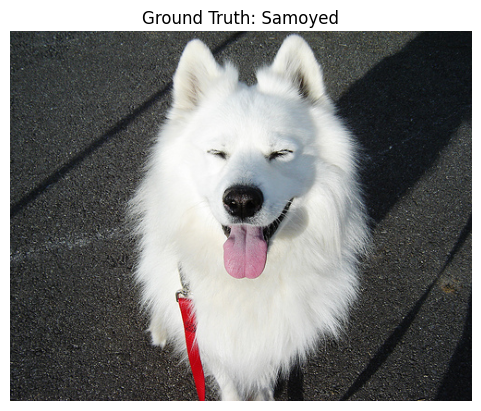

Querying model...
Prompt: 
"<start_of_turn>user
<image>Describe the image.<end_of_turn>
<start_of_turn>model
"


ValueError: Prompt contained 0 image tokens but received 1 images.

In [17]:
run_and_display_example("pets")

### Example 2: Classifying Textures with Qwen-VL

In [ ]:
run_and_display_example("dtd")

### Example 3: Classifying CIFAR-10 with BakLLaVA (Mistral base)

In [ ]:
run_and_display_example("cifar10")

### Example 4: Zero-Shot with Gemma3

Gemma3's architecture is better suited for simple instruction following (like captioning or VQA) out-of-the-box rather than the complex, interleaved few-shot format of LLaVA. Here we'll do a simpler zero-shot query.

In [7]:
run_and_display_example("flowers")


Running example for MODEL: GOOGLE/GEMMA-3-12B-IT on DATASET: FLOWERS



ValueError: Unsupported model for prompt creation.